In [2]:
# =============================================================================
# TCC — Caracterização Não Supervisionada de Perturbações Elétricas
# Rafael Benzaquem Neto | UFRR — ECAI 4.0
#
# MÓDULO 1 — Pré-processamento dos Dados (Seção 4.3.1) — VERSÃO CORRIGIDA
#
# Correções aplicadas com base na análise da Célula X:
#   C1 — WINDOW_SIZE inferido por arquivo (não constante global)
#   C2 — V_NOMINAL_PEAK_KV inferido dos ciclos pré-falta por arquivo
#   C3 — SPC extraído do matAux (n_amostras col 10), não de constante global
#   C4 — Linha incompleta "wz =" corrigida na validação de eventos
#   C5 — Rejeição de arquivos com V_NOM anômalo (outliers como Q0001021)
#   C6 — Padronização para WINDOW_SIZE comum (resample para 384 amostras)
#   C7 — Metadados de inferência salvos por arquivo para rastreabilidade
# =============================================================================
# Compatível com Google Colab. Execute célula a célula (▶).
# =============================================================================

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 1 — Instalação de dependências
# ─────────────────────────────────────────────────────────────────────────────
#!pip install scipy matplotlib numpy pandas --quiet

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import os
import glob
import warnings
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
#from google.colab import drive

warnings.filterwarnings('ignore')
np.random.seed(42)

print("✅ Bibliotecas carregadas com sucesso.")

✅ Bibliotecas carregadas com sucesso.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA X — Célula para análise de todos os dados disponíveis e correção do código
# ─────────────────────────────────────────────────────────────────────────────

import scipy.io
import numpy as np
import os
import pandas as pd

def tensao_nominal_pico_kV(sinal):
     v_rms = np.sqrt(np.mean(sinal**2))
     v_pico_kv = (v_rms * np.sqrt(2))
     if v_pico_kv > 1000:
        return v_pico_kv / 1000
     return v_pico_kv

def amostras_por_ciclo_2(sinal):
    zero_crossings = np.where(np.diff(np.sign(sinal)))[0]

    # A distância entre o 1º e o 3º cruzamento por zero é exatamente um ciclo completo
    return zero_crossings[2] - zero_crossings[0]

def amostras_por_ciclo_1(sinal):
    # Centralizamos o sinal para garantir que o zero seja o ponto médio real
    sinal_centrado = sinal - np.mean(sinal)
    # Identificamos onde o sinal cruza de negativo para positivo
    pos_crossings = np.where((sinal_centrado[:-1] < 0) & (sinal_centrado[1:] >= 0))[0]
    if len(pos_crossings) > 1:
    # Média da distância entre os cruzamentos para maior precisão
        return np.mean(np.diff(pos_crossings))
    return 0

def analisar_arquivo_sem_aux(caminho_arquivo):
    try:
        # Carregar o arquivo .mat
        data = scipy.io.loadmat(caminho_arquivo)
        nome_arquivo = os.path.basename(caminho_arquivo)

        # 1. Contar itens por arquivo (len(data.items()))
        qtd_itens = len(data.items())

        # 2. Localizar um canal de tensão para análise (ex: matXVa)
        canais_v = [k for k in data.keys() if 'matXV' in k and 'Diff' not in k]
        if not canais_v:
            # Se não achar o padrão, tenta qualquer um que comece com matXV
            canais_v = [k for k in data.keys() if 'matXV' in k]

        if not canais_v:
            return None

        # Pegamos o sinal da primeira fase encontrada
        sinal_a = data[canais_v[0]].flatten()
        sinal_b = data[canais_v[1]].flatten()
        sinal_c = data[canais_v[2]].flatten()

        # 3. Estimativa de Amostras por Ciclo (via cruzamento por zero)

        amostras_por_ciclo_a = amostras_por_ciclo_2(sinal_a)
        amostras_por_ciclo_b = amostras_por_ciclo_2(sinal_b)
        amostras_por_ciclo_c = amostras_por_ciclo_2(sinal_c)

        # 4. Tensão Nominal de Fase (Pico) — kV
        v_pico_kv_a = tensao_nominal_pico_kV(sinal_a)
        v_pico_kv_b = tensao_nominal_pico_kV(sinal_b)
        v_pico_kv_c = tensao_nominal_pico_kV(sinal_c)

        return {
            "Arquivo": nome_arquivo,
            "Itens_no_Mat": qtd_itens,
            "Amostras_por_Ciclo": round(amostras_por_ciclo_a, 2),
            "Amostras_por_Ciclo_B": round(amostras_por_ciclo_b, 2),
            "Amostras_por_Ciclo_C": round(amostras_por_ciclo_c, 2),
            "Tensao_Pico_kV_A": round(v_pico_kv_a, 3),
            "Tensao_Pico_kV_B": round(v_pico_kv_b, 3),
            "Tensao_Pico_kV_C": round(v_pico_kv_c, 3),
            "Qtd_Amostras": len(sinal_a)
        }
    except Exception as e:
        print(f"Erro ao processar {caminho_arquivo}: {e}")
        return None

def processar_pastas(pastas):
    resultados = []
    for p in pastas:
        if not os.path.exists(p): continue
        for f in os.listdir(p):
            if f.endswith('.mat'):
                res = analisar_arquivo_sem_aux(os.path.join(p, f))
                if res: resultados.append(res)
    return pd.DataFrame(resultados)

# --- EXECUÇÃO ---
# Substitua pelos caminhos das suas pastas
minhas_pastas = ['./0_dados_brutos/Data from Sub3/Results/', './0_dados_brutos/Data from Sub8/Results/']
df = processar_pastas(minhas_pastas)

# Exibir resultado final
print(df.to_string(index=False))

               Arquivo  Itens_no_Mat  Amostras_por_Ciclo  Amostras_por_Ciclo_B  Amostras_por_Ciclo_C  Tensao_Pico_kV_A  Tensao_Pico_kV_B  Tensao_Pico_kV_C  Qtd_Amostras
Q0000976_detection.mat            54                  64                    64                    64            95.420            95.274            95.639          2688
Q0000924_detection.mat            54                  64                    64                    64            95.689            95.515            95.826          4992
Q0000852_detection.mat            54                  64                    64                    63            94.843            94.618            95.123         16896
Q0000868_detection.mat            54                  64                    64                    64            95.198            94.986            95.450          9984
Q0001010_detection.mat            54                  64                    64                    64            95.783            95.582            95.903 

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 3 — Configurações globais
#
# ATENÇÃO: Os parâmetros abaixo são VALORES DE REFERÊNCIA e FALLBACK.
# O pipeline agora infere SPC e V_NOM dinamicamente de cada arquivo .mat.
# Altere apenas se souber o valor exato do seu sistema elétrico.
# ─────────────────────────────────────────────────────────────────────────────

# ── Parâmetros de referência do sistema elétrico ──────────────────────────────
FREQ_NOMINAL_HZ   = 60.0   # Hz — frequência nominal (60 Hz confirmado nos dados)

# CORREÇÃO C1/C3: SPC e WINDOW_SIZE corretos, confirmados pela Célula X e matAux
# A Célula X confirmou SPC=64 amostras/ciclo (o valor 384 anterior estava errado:
# usava SPC=24 de uma versão anterior do pipeline com dados diferentes).
# 384 amostras / 64 SPC = 6 ciclos por janela de evento.
SAMPLES_PER_CYCLE_DEFAULT = 64    # amostras/ciclo (padrão da base; inferido por arquivo)
NUM_CYCLES_DEFAULT        = 6     # ciclos por janela = 384/64
WINDOW_SIZE_DEFAULT       = SAMPLES_PER_CYCLE_DEFAULT * NUM_CYCLES_DEFAULT  # 384

# CORREÇÃO C2: V_NOM é inferido dos ciclos pré-falta de cada arquivo.
# Este valor é o fallback caso a inferência falhe.
V_NOMINAL_PEAK_KV_DEFAULT = 95.5  # kV — mediana real observada na base (Célula X)

# ── Limites de sanidade para rejeição de arquivos anômalos (CORREÇÃO C5) ─────
# Arquivos cujo V_NOM inferido sair desta faixa são descartados.
V_NOM_MIN_KV = 80.0    # kV — mínimo aceitável (abaixo = sinal fora de escala)
V_NOM_MAX_KV = 115.0   # kV — máximo aceitável (acima = provável erro de escala)
# Arquivos cujo SPC inferido sair desta faixa também são descartados.
SPC_MIN = 56           # amostras/ciclo mínimo aceitável (±12.5% de 64)
SPC_MAX = 72           # amostras/ciclo máximo aceitável

# ── Canais do arquivo .mat ────────────────────────────────────────────────────
VOLTAGE_KEYS = ['matXVa', 'matXVb', 'matXVc']
CURRENT_KEYS = ['matXIa', 'matXIb', 'matXIc']
AUX_KEY      = 'matAux'

# Índices do matAux (confirmados na inspeção dos dados)
AUX_COL_NAMES = [
    'tipo_evento',   # col 0  — código do tipo de perturbação
    'amp_max_pos',   # col 1  — amplitude máxima positiva
    'amp_max_neg',   # col 2  — amplitude máxima negativa
    'V_rms_max',     # col 3  — tensão RMS máxima (p.u. do matAux)
    'V_rms_min',     # col 4  — tensão RMS mínima (p.u. do matAux)
    'ts_inicio',     # col 5  — timestamp de início (ms)
    'ts_fim',        # col 6  — timestamp de fim (ms)
    'duracao_ciclos',# col 7  — duração da perturbação em ciclos
    'duracao_ms',    # col 8  — duração em ms
    'freq_medida_hz',# col 9  — frequência medida no registrador
    'n_amostras',    # col 10 — amostras do evento (= SPC nesta base!)
    'n_ciclos_pre',  # col 11 — ciclos de pré-falta na janela
    'n_ciclos_pos',  # col 12 — ciclos de pós-falta na janela
    'flag_A',        # col 13 — flag fase A afetada (+1) / não afetada (-1)
    'flag_B',        # col 14 — flag fase B
    'flag_C',        # col 15 — flag fase C
    'flag_N',        # col 16 — flag neutro
    'flag_extra',    # col 17 — campo extra
    'ts_pico',       # col 18 — timestamp do pico
    'codigo_evento', # col 19 — código interno do evento
]

# ── Caminhos ──────────────────────────────────────────────────────────────────
#drive.mount('/content/drive')
from pathlib import Path
from datetime import datetime

DATA_DIR = Path('./0_dados_brutos')

# ── Diretório de saída com subpasta exclusiva por execução ───────────────────
# Formato: exec_YYYYMMDD_HHMM_<FREQ>_<SPC>_<CICLOS>_<JANELA>
# Exemplo: ./1_dados_preprocessados/exec_20231027_1430_60_64_6_384/
_BASE_OUTPUT_DIR = Path('./1_dados_preprocessados')
_ts = datetime.now().strftime('%Y%m%d_%H%M')
_run_name = (
    f"exec_{_ts}"
    f"_{int(FREQ_NOMINAL_HZ)}"
    f"_{SAMPLES_PER_CYCLE_DEFAULT}"
    f"_{NUM_CYCLES_DEFAULT}"
    f"_{WINDOW_SIZE_DEFAULT}"
)
OUTPUT_DIR = _BASE_OUTPUT_DIR / _run_name
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Configurações carregadas.")
print(f"   SPC padrão        : {SAMPLES_PER_CYCLE_DEFAULT} amostras/ciclo")
print(f"   Ciclos por janela  : {NUM_CYCLES_DEFAULT}")
print(f"   WINDOW_SIZE padrão : {WINDOW_SIZE_DEFAULT} amostras")
print(f"   V_NOM fallback     : {V_NOMINAL_PEAK_KV_DEFAULT} kV")
print(f"   Faixa V_NOM válida : [{V_NOM_MIN_KV}, {V_NOM_MAX_KV}] kV")
print(f"   Saída em           : {OUTPUT_DIR}")

✅ Configurações carregadas.
   SPC padrão        : 64 amostras/ciclo
   Ciclos por janela  : 6
   WINDOW_SIZE padrão : 384 amostras
   V_NOM fallback     : 95.5 kV
   Faixa V_NOM válida : [80.0, 115.0] kV
   Saída em           : 1_dados_preprocessados/exec_20260408_1953_60_64_6_384


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 4 — Funções de inferência adaptativa de parâmetros
#
# CORREÇÃO C3: SPC é extraído do matAux (col 10 = n_amostras),
# que na base desta subestação corresponde ao SPC real (64).
# Zero-crossing como fallback quando matAux não é confiável.
#
# CORREÇÃO C2: V_NOM é calculado a partir dos ciclos pré-falta reais
# (usando n_ciclos_pre do matAux, col 11), não do sinal completo.
# ─────────────────────────────────────────────────────────────────────────────

def inferir_spc_por_evento(sinal_1d: np.ndarray,
                            spc_aux: int = 0) -> int:
    """
    Infere o número de amostras por ciclo de um sinal 1D.

    Estratégia (prioridade decrescente):
      1. Usa spc_aux do matAux (col 10) se for valor plausível (32–128)
      2. Fallback: cruzamento por zero no próprio evento

    Retorna spc como int.
    """
    # Prioridade 1: matAux
    if 32 <= spc_aux <= 128:
        return int(spc_aux)

    # Prioridade 2: zero-crossing no evento individual
    sinal_c = sinal_1d - np.mean(sinal_1d)
    zc = np.where(np.diff(np.sign(sinal_c)))[0]
    if len(zc) >= 3:
        distancias = np.diff(zc)
        spc_zc = int(np.round(np.median(distancias) * 2))
        if 32 <= spc_zc <= 128:
            return spc_zc

    return SAMPLES_PER_CYCLE_DEFAULT


def inferir_spc_arquivo(dados: dict, aux: np.ndarray) -> int:
    """
    Determina o SPC dominante para t0do o arquivo usando matAux col 10
    e confirma com zero-crossing na mediana dos eventos.

    Retorna o SPC como int.
    """
    # Extrair n_amostras do matAux (col 10)
    n_amostras_col = aux[:, 10].astype(int)
    vals_plaus = n_amostras_col[(n_amostras_col >= 32) & (n_amostras_col <= 128)]
    if len(vals_plaus) > 0:
        spc_aux = int(np.median(vals_plaus))
    else:
        spc_aux = 0

    # Confirmar com zero-crossing no 1º canal de tensão (evento central)
    canal = dados[VOLTAGE_KEYS[0]]
    idx_mid = len(canal) // 2
    spc_zc = inferir_spc_por_evento(canal[idx_mid], spc_aux=0)

    if spc_aux > 0 and abs(spc_aux - spc_zc) <= 4:
        return spc_aux   # matAux e zero-crossing concordam
    if spc_aux > 0:
        return spc_aux   # usa matAux mesmo com pequena divergência
    return spc_zc        # fallback puro de zero-crossing


def inferir_vnominal_arquivo(dados: dict, aux: np.ndarray,
                              spc: int) -> float:
    """
    Calcula V_nominal_pico usando SOMENTE os ciclos PRÉ-FALTA
    (n_ciclos_pre do matAux, col 11), que representam a tensão nominal real
    do sistema antes da perturbação.

    Estratégia:
      - Para cada evento, extrai os ciclos pré-falta (Va, Vb, Vc)
      - Calcula V_pico = max|sinal| nos ciclos pré-falta
      - Retorna a mediana entre todos os eventos e fases (robusto a outliers)
    """
    n_eventos = aux.shape[0]
    v_pico_lista = []

    for i in range(n_eventos):
        n_pre = int(aux[i, 11])   # n_ciclos_pre
        if n_pre <= 0:
            n_pre = 3             # fallback: 3 ciclos pré-falta estimados
        n_amostras_pre = n_pre * spc

        for chave in VOLTAGE_KEYS:
            sinal = dados[chave][i]
            if len(sinal) > n_amostras_pre:
                segmento_pre = sinal[:n_amostras_pre]
            else:
                segmento_pre = sinal
            v_pico = float(np.max(np.abs(segmento_pre)))
            if v_pico > 1.0:   # ignorar sinais já normalizados ou zero
                v_pico_lista.append(v_pico)

    if len(v_pico_lista) == 0:
        return V_NOMINAL_PEAK_KV_DEFAULT

    return float(np.median(v_pico_lista))


def arquivo_e_valido(nome: str, spc: int, v_nom: float) -> tuple[bool, str]:
    """
    Verifica se os parâmetros inferidos são fisicamente plausíveis.
    Rejeita arquivos com SPC ou V_NOM anômalos.
    Retorna (valido: bool, motivo: str).
    """
    if not (SPC_MIN <= spc <= SPC_MAX):
        return False, f"SPC={spc} fora de [{SPC_MIN}, {SPC_MAX}]"
    if not (V_NOM_MIN_KV <= v_nom <= V_NOM_MAX_KV):
        return False, f"V_NOM={v_nom:.2f} kV fora de [{V_NOM_MIN_KV}, {V_NOM_MAX_KV}] kV"
    return True, "ok"


print("✅ Funções de inferência adaptativa definidas.")

✅ Funções de inferência adaptativa definidas.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 5 — Carregamento e validação de eventos
#
# ─────────────────────────────────────────────────────────────────────────────

def carregar_mat(caminho_arquivo: str) -> dict | None:
    """
    Carrega um arquivo .mat e retorna os canais de tensão, corrente e matAux.
    Retorna None se o arquivo estiver corrompido ou incompleto.
    """
    try:
        mat = scipy.io.loadmat(caminho_arquivo)
    except Exception as e:
        print(f"  ⚠️  Erro ao carregar '{Path(caminho_arquivo).name}': {e}")
        return None

    chaves_obrigatorias = VOLTAGE_KEYS + [AUX_KEY]
    for chave in chaves_obrigatorias:
        if chave not in mat:
            print(f"  ⚠️  Chave ausente: '{chave}' em '{Path(caminho_arquivo).name}'")
            return None

    dados = {k: mat[k] for k in VOLTAGE_KEYS + CURRENT_KEYS + [AUX_KEY]
             if k in mat}
    return dados


def validar_evento(sinal: np.ndarray,
                   window_size: int,
                   idx_evento: int,
                   nome_canal: str,
                   nome_arquivo: str) -> bool:
    """
    Valida um único evento com o WINDOW_SIZE real do arquivo.
    Usa window_size passado como parâmetro, não constante global.
    Critérios:
      1. Tamanho correto (window_size amostras)
      2. Sem NaN ou Inf
      3. Variância > 0 (sinal não é constante)
      4. Amplitude plausível (sinal não está zerado ou saturado)
    """
    if sinal.shape[0] != window_size:
        print(f"    ✗ [{nome_arquivo}] Evento {idx_evento} — {nome_canal}: "
              f"tamanho {sinal.shape[0]} ≠ {window_size}")
        return False

    if not np.isfinite(sinal).all():
        print(f"    ✗ [{nome_arquivo}] Evento {idx_evento} — {nome_canal}: NaN/Inf")
        return False

    if np.var(sinal) < 1e-10:
        print(f"    ✗ [{nome_arquivo}] Evento {idx_evento} — {nome_canal}: sinal constante")
        return False

    # Sinal muito fraco — provável canal com falha de instrumentação
    if np.max(np.abs(sinal)) < 1.0:
        print(f"    ✗ [{nome_arquivo}] Evento {idx_evento} — {nome_canal}: "
              f"amplitude < 1 kV (canal provavelmente defeituoso)")
        return False

    return True


def validar_arquivo(dados: dict, window_size: int, nome_arquivo: str) -> np.ndarray:
    """
    Valida todos os eventos do arquivo com o WINDOW_SIZE real.
    Retorna máscara booleana de eventos válidos.
    """
    n_eventos = dados[VOLTAGE_KEYS[0]].shape[0]
    mascara   = np.ones(n_eventos, dtype=bool)

    for idx in range(n_eventos):
        for chave in VOLTAGE_KEYS:
            sinal = dados[chave][idx]
            if not validar_evento(sinal, window_size, idx, chave, nome_arquivo):
                mascara[idx] = False
                break

    n_removidos = n_eventos - mascara.sum()
    if n_removidos > 0:
        print(f"  ℹ️  {n_removidos} evento(s) removido(s) por falha de validação.")

    return mascara


print("✅ Funções de validação definidas.")


✅ Funções de validação definidas.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 6 — Normalização p.u. e padronização de janela
#
# CORREÇÃO C1/C6: Cada arquivo usa seu próprio V_NOM e SPC.
# Para garantir que todos os tensores tenham o mesmo WINDOW_SIZE
# (necessário para concatenação e entrada no CAE), aplica-se
# reamostragem (resample) quando necessário.
#
# Referência: IEEE Std 1159:2019 — normalização pela tensão nominal de pico
# preserva a "retained voltage" (tensão remanescente) para correta
# classificação de sags, swells e interrupções.
# ─────────────────────────────────────────────────────────────────────────────

def normalizar_pu(sinais: np.ndarray, v_nominal_pico: float) -> np.ndarray:
    """
    Normaliza sinais de tensão para por unidade (p.u.).
    v_nominal_pico é o V_NOM inferido dos ciclos pré-falta deste arquivo.
    """
    return sinais / v_nominal_pico


def calcular_vrms_por_ciclo(sinal_pu: np.ndarray, spc: int) -> np.ndarray:
    """
    Calcula RMS de cada ciclo de um sinal normalizado em p.u.
    Usa o SPC real do arquivo.
    """
    n_ciclos = len(sinal_pu) // spc
    rms = np.zeros(n_ciclos)
    for i in range(n_ciclos):
        seg = sinal_pu[i * spc:(i + 1) * spc]
        rms[i] = np.sqrt(np.mean(seg ** 2))
    return rms


def padronizar_window(sinal: np.ndarray,
                      window_size_arquivo: int,
                      window_size_alvo: int) -> np.ndarray:
    """
    CORREÇÃO C6: Padroniza o sinal para window_size_alvo amostras
    usando interpolação linear quando necessário.

    Se window_size_arquivo == window_size_alvo: retorna sinal sem alteração.
    Se diferente: reamostrage por interpolação (preserva forma de onda).
    """
    if window_size_arquivo == window_size_alvo:
        return sinal
    x_orig  = np.linspace(0, 1, window_size_arquivo)
    x_novo  = np.linspace(0, 1, window_size_alvo)
    return np.interp(x_novo, x_orig, sinal)


print("✅ Funções de normalização e padronização definidas.")


✅ Funções de normalização e padronização definidas.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 7 — Pipeline principal: preprocessar_arquivo
#
# Integra todas as correções em um único pipeline por arquivo.
# Retorna também os metadados de inferência (SPC, V_NOM inferidos)
# para rastreabilidade completa (CORREÇÃO C7).
# ─────────────────────────────────────────────────────────────────────────────

# WINDOW_SIZE alvo para o tensor final (deve ser igual ao maior SPC × NUM_CYCLES)
# Com SPC=64 e 6 ciclos: WINDOW_SIZE_ALVO = 384
WINDOW_SIZE_ALVO = WINDOW_SIZE_DEFAULT   # 384 — padrão da base

def preprocessar_arquivo(caminho_arquivo: str
                          ) -> tuple | None:
    """
    Executa o pipeline completo de pré-processamento em um arquivo .mat.

    Etapas:
      1. Carregamento e validação estrutural
      2. Inferência de SPC e V_NOM por arquivo (CORREÇÕES C2/C3)
      3. Rejeição se parâmetros anômalos (CORREÇÃO C5)
      4. Validação evento a evento com WINDOW_SIZE real (CORREÇÃO C4)
      5. Normalização p.u. com V_NOM inferido
      6. Padronização para WINDOW_SIZE_ALVO (CORREÇÃO C6)
      7. Extração de metadados + metadados de inferência (CORREÇÃO C7)

    Retorna
    -------
    X_pu     : np.ndarray (N_val, WINDOW_SIZE_ALVO, 3) — tensores p.u.
    X_raw_kv : np.ndarray (N_val, WINDOW_SIZE_ALVO, 3) — tensores em kV
    df_aux   : pd.DataFrame — metadados dos eventos
    meta_inf : dict — metadados da inferência (SPC, V_NOM, etc.)
    """
    nome = Path(caminho_arquivo).name

    # ── 1. Carregamento ───────────────────────────────────────────────────────
    dados = carregar_mat(caminho_arquivo)
    if dados is None:
        return None

    aux = dados[AUX_KEY]
    n_total = dados[VOLTAGE_KEYS[0]].shape[0]

    # ── 2. Inferência adaptativa de SPC e V_NOM ───────────────────────────────
    spc   = inferir_spc_arquivo(dados, aux)
    v_nom = inferir_vnominal_arquivo(dados, aux, spc)
    window_size = dados[VOLTAGE_KEYS[0]].shape[1]  # amostras reais por evento

    # ── 3. Rejeição de arquivos anômalos (CORREÇÃO C5) ───────────────────────
    valido, motivo = arquivo_e_valido(nome, spc, v_nom)
    if not valido:
        print(f"  ✗ [{nome}] Arquivo REJEITADO: {motivo}")
        return None

    # ── 4. Validação evento a evento ─────────────────────────────────────────
    mascara  = validar_arquivo(dados, window_size, nome)
    n_validos = int(mascara.sum())

    if n_validos == 0:
        print(f"  ⚠️  [{nome}] Nenhum evento válido. Arquivo ignorado.")
        return None

    # ── 5. Normalização p.u. e padronização ──────────────────────────────────
    canais_pu, canais_raw = [], []
    for chave in VOLTAGE_KEYS:
        sinal_raw = dados[chave][mascara]            # (N_val, window_size)
        sinal_pu  = normalizar_pu(sinal_raw, v_nom)  # normaliza com V_NOM real

        # CORREÇÃO C6: padronizar para WINDOW_SIZE_ALVO se necessário
        if window_size != WINDOW_SIZE_ALVO:
            sinal_pu  = np.array([padronizar_window(s, window_size, WINDOW_SIZE_ALVO)
                                  for s in sinal_pu])
            sinal_raw = np.array([padronizar_window(s, window_size, WINDOW_SIZE_ALVO)
                                  for s in sinal_raw])

        canais_pu.append(sinal_pu)
        canais_raw.append(sinal_raw)

    X_pu     = np.stack(canais_pu,  axis=-1)  # (N_val, WINDOW_SIZE_ALVO, 3)
    X_raw_kv = np.stack(canais_raw, axis=-1)

    # ── 6. Metadados dos eventos + metadados de inferência ───────────────────
    aux_filtrado = aux[mascara]
    n_cols = min(len(AUX_COL_NAMES), aux_filtrado.shape[1])
    df_aux = pd.DataFrame(aux_filtrado[:, :n_cols],
                          columns=AUX_COL_NAMES[:n_cols])
    df_aux['arquivo_origem'] = nome

    # CORREÇÃO C7: metadados de inferência para rastreabilidade
    meta_inf = {
        'arquivo'          : nome,
        'spc_inferido'     : spc,
        'v_nom_kv_inferido': round(v_nom, 4),
        'window_size_orig' : window_size,
        'window_size_alvo' : WINDOW_SIZE_ALVO,
        'resampled'        : (window_size != WINDOW_SIZE_ALVO),
        'n_eventos_total'  : n_total,
        'n_eventos_validos': n_validos,
        'n_eventos_rejeit' : n_total - n_validos,
        'v_nom_fonte'      : 'pre-falta matAux',
    }

    print(f"   ✅ SPC={spc}  V_NOM={v_nom:.2f} kV  "
          f"eventos={n_validos}/{n_total}  "
          f"shape={X_pu.shape}")

    return X_pu, X_raw_kv, df_aux, meta_inf


print("✅ Função preprocessar_arquivo definida.")


✅ Função preprocessar_arquivo definida.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 8 — Pipeline em lote: preprocessar_diretorio
# ─────────────────────────────────────────────────────────────────────────────

def preprocessar_diretorio(diretorio: str
                            ) -> tuple[np.ndarray, np.ndarray,
                                       pd.DataFrame, pd.DataFrame]:
    """
    Processa todos os .mat de um diretório (recursivo).

    Retorna
    -------
    X_pu_total    : np.ndarray (N_total, WINDOW_SIZE_ALVO, 3)
    X_raw_total   : np.ndarray (N_total, WINDOW_SIZE_ALVO, 3)
    df_aux_total  : pd.DataFrame — metadados dos eventos
    df_inferencia : pd.DataFrame — log de inferência por arquivo (CORREÇÃO C7)
    """
    arquivos = sorted(glob.glob(
        os.path.join(diretorio, '**', '*.mat'), recursive=True
    ))
    print(f"🗂️  {len(arquivos)} arquivo(s) .mat encontrado(s) em '{diretorio}'")

    lista_pu, lista_raw, lista_aux, lista_meta = [], [], [], []
    n_rejeitados = 0

    for arq in arquivos:
        nome = Path(arq).name
        print(f"\n📂 Processando: {nome}")

        resultado = preprocessar_arquivo(arq)
        if resultado is None:
            n_rejeitados += 1
            continue

        X_pu, X_raw, df_aux, meta_inf = resultado
        lista_pu.append(X_pu)
        lista_raw.append(X_raw)
        lista_aux.append(df_aux)
        lista_meta.append(meta_inf)

    if not lista_pu:
        raise RuntimeError("Nenhum arquivo válido encontrado. Verifique os caminhos.")

    X_pu_total  = np.concatenate(lista_pu,  axis=0)
    X_raw_total = np.concatenate(lista_raw, axis=0)
    df_total    = pd.concat(lista_aux, ignore_index=True)
    df_inferencia = pd.DataFrame(lista_meta)

    # Verificação de sanidade da normalização p.u.
    v_max_pu = float(X_pu_total[:, :, 0].max())
    v_min_pu = float(X_pu_total[:, :, 0].min())
    alerta_pu = ""
    if abs(v_max_pu) > 1.5 or abs(v_min_pu) > 1.5:
        alerta_pu = "  ⚠️  Valores além de ±1.5 p.u. — verificar V_NOM dos arquivos."

    print(f"\n{'='*57}")
    print(f"📊 RESUMO FINAL DO PRÉ-PROCESSAMENTO")
    print(f"   Arquivos processados  : {len(lista_meta)}")
    print(f"   Arquivos rejeitados   : {n_rejeitados}")
    print(f"   Total eventos válidos : {X_pu_total.shape[0]}")
    print(f"   Shape do tensor p.u.  : {X_pu_total.shape}")
    print(f"   Faixa p.u. (Va)       : [{v_min_pu:.4f}, {v_max_pu:.4f}]{alerta_pu}")
    print(f"   SPC inferido (mediana): {int(df_inferencia['spc_inferido'].median())}")
    print(f"   V_NOM inferido (med.) : {df_inferencia['v_nom_kv_inferido'].median():.3f} kV")
    if df_inferencia['resampled'].any():
        n_rs = df_inferencia['resampled'].sum()
        print(f"   Arquivos reamostrados : {n_rs} (window_size diferente de {WINDOW_SIZE_ALVO})")
    print(f"{'='*57}")

    return X_pu_total, X_raw_total, df_total, df_inferencia


print("✅ Pipeline em lote definido.")


✅ Pipeline em lote definido.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 9 — Execução
# ─────────────────────────────────────────────────────────────────────────────

# Modo A — arquivo único (para teste):
# SINGLE_FILE = './0_dados_brutos/Data from Sub3/Results/Q0000833_detection.mat'
# resultado = preprocessar_arquivo(SINGLE_FILE)
# if resultado:
#     X_pu, X_raw_kv, df_aux, meta_inf = resultado

# Modo B — diretório completo (produção):
X_pu, X_raw_kv, df_aux, df_inferencia = preprocessar_diretorio(DATA_DIR)


🗂️  378 arquivo(s) .mat encontrado(s) em '0_dados_brutos'

📂 Processando: Q0000833_detection.mat
   ✅ SPC=64  V_NOM=96.78 kV  eventos=48/48  shape=(48, 384, 3)

📂 Processando: Q0000834_detection.mat
   ✅ SPC=64  V_NOM=96.75 kV  eventos=44/44  shape=(44, 384, 3)

📂 Processando: Q0000835_detection.mat
   ✅ SPC=64  V_NOM=96.85 kV  eventos=27/27  shape=(27, 384, 3)

📂 Processando: Q0000836_detection.mat
   ✅ SPC=64  V_NOM=96.64 kV  eventos=14/14  shape=(14, 384, 3)

📂 Processando: Q0000837_detection.mat
   ✅ SPC=64  V_NOM=96.59 kV  eventos=15/15  shape=(15, 384, 3)

📂 Processando: Q0000838_detection.mat
   ✅ SPC=64  V_NOM=97.08 kV  eventos=11/11  shape=(11, 384, 3)

📂 Processando: Q0000839_detection.mat
   ✅ SPC=64  V_NOM=97.19 kV  eventos=8/8  shape=(8, 384, 3)

📂 Processando: Q0000840_detection.mat
   ✅ SPC=64  V_NOM=96.69 kV  eventos=30/30  shape=(30, 384, 3)

📂 Processando: Q0000841_detection.mat
   ✅ SPC=64  V_NOM=96.72 kV  eventos=54/54  shape=(54, 384, 3)

📂 Processando: Q0000842_de

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 10 — Salvar dados pré-processados
# ─────────────────────────────────────────────────────────────────────────────

def salvar_preprocessado(X_pu, X_raw_kv, df_aux, df_inferencia,
                          diretorio_saida=OUTPUT_DIR, prefixo='dataset'):
    os.makedirs(diretorio_saida, exist_ok=True)
    np.save(os.path.join(diretorio_saida, f'{prefixo}_X_pu.npy'),     X_pu)
    np.save(os.path.join(diretorio_saida, f'{prefixo}_X_raw_kv.npy'), X_raw_kv)
    df_aux.to_csv(os.path.join(diretorio_saida, f'{prefixo}_metadata.csv'), index=False)
    # CORREÇÃO C7: salvar log de inferência
    df_inferencia.to_csv(os.path.join(diretorio_saida, f'{prefixo}_inferencia.csv'), index=False)

    print(f"\n💾 Dados salvos em '{diretorio_saida}':")
    print(f"   • {prefixo}_X_pu.npy        — shape {X_pu.shape}")
    print(f"   • {prefixo}_X_raw_kv.npy    — shape {X_raw_kv.shape}")
    print(f"   • {prefixo}_metadata.csv     — {len(df_aux)} eventos")
    print(f"   • {prefixo}_inferencia.csv   — log SPC/V_NOM por arquivo")


try:
    salvar_preprocessado(X_pu, X_raw_kv, df_aux, df_inferencia)
except NameError:
    print("⚠️  Execute a Célula 9 antes de salvar.")


💾 Dados salvos em '1_dados_preprocessados/exec_20260408_1953_60_64_6_384':
   • dataset_X_pu.npy        — shape (11928, 384, 3)
   • dataset_X_raw_kv.npy    — shape (11928, 384, 3)
   • dataset_metadata.csv     — 11928 eventos
   • dataset_inferencia.csv   — log SPC/V_NOM por arquivo


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 11 — Diagnóstico de qualidade da inferência
#
# Analisa o log de inferência e emite alertas sobre arquivos suspeitos.
# ─────────────────────────────────────────────────────────────────────────────

def diagnosticar_inferencia(df_inf: pd.DataFrame) -> None:
    """
    Analisa o DataFrame de inferência e imprime um relatório de qualidade.
    """
    print("\n" + "=" * 57)
    print("📊 DIAGNÓSTICO DA INFERÊNCIA ADAPTATIVA")
    print("=" * 57)

    # Distribuição de SPC
    spc_counts = df_inf['spc_inferido'].value_counts().sort_index()
    print(f"\n  Distribuição de SPC inferido:")
    for spc_val, cnt in spc_counts.items():
        flag = " ⚠️" if spc_val not in (64, SAMPLES_PER_CYCLE_DEFAULT) else ""
        print(f"    SPC={spc_val}: {cnt} arquivo(s){flag}")

    # Distribuição de V_NOM
    v_med  = df_inf['v_nom_kv_inferido'].median()
    v_std  = df_inf['v_nom_kv_inferido'].std()
    v_min_ = df_inf['v_nom_kv_inferido'].min()
    v_max_ = df_inf['v_nom_kv_inferido'].max()
    print(f"\n  V_NOM inferido (kV):")
    print(f"    Mediana : {v_med:.3f}  |  Std: {v_std:.3f}")
    print(f"    Faixa   : [{v_min_:.3f}, {v_max_:.3f}]")

    # Arquivos com V_NOM fora de ±10% da mediana
    limiar_inf = v_med * 0.90
    limiar_sup = v_med * 1.10
    suspeitos = df_inf[
        (df_inf['v_nom_kv_inferido'] < limiar_inf) |
        (df_inf['v_nom_kv_inferido'] > limiar_sup)
    ]
    if len(suspeitos) > 0:
        print(f"\n  ⚠️  {len(suspeitos)} arquivo(s) com V_NOM fora de ±10% da mediana:")
        for _, row in suspeitos.iterrows():
            print(f"    {row['arquivo']:35s}  V_NOM={row['v_nom_kv_inferido']:.2f} kV")

    # Arquivos reamostrados
    rs = df_inf[df_inf['resampled']]
    if len(rs) > 0:
        print(f"\n  ℹ️  {len(rs)} arquivo(s) reamostrados para {WINDOW_SIZE_ALVO} amostras.")

    # Taxa de aproveitamento
    total_ev = df_inf['n_eventos_total'].sum()
    validos  = df_inf['n_eventos_validos'].sum()
    print(f"\n  Taxa de aproveitamento: {validos}/{total_ev} "
          f"({100*validos/total_ev:.1f}%)")
    print("=" * 57)


try:
    diagnosticar_inferencia(df_inferencia)
except NameError:
    print("⚠️  Execute a Célula 9 antes.")


📊 DIAGNÓSTICO DA INFERÊNCIA ADAPTATIVA

  Distribuição de SPC inferido:
    SPC=64: 377 arquivo(s)

  V_NOM inferido (kV):
    Mediana : 96.558  |  Std: 0.499
    Faixa   : [94.745, 97.464]

  Taxa de aproveitamento: 11928/12068 (98.8%)


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 12 — Visualização de diagnóstico
# ─────────────────────────────────────────────────────────────────────────────

def plotar_diagnostico_inferencia(df_inf: pd.DataFrame,
                                   output_dir: str) -> None:
    """
    Plota: histograma de V_NOM inferido e boxplot de V_NOM por arquivo.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Histograma V_NOM
    axes[0].hist(df_inf['v_nom_kv_inferido'], bins=30,
                 color='#457b9d', edgecolor='black', alpha=0.85)
    med = df_inf['v_nom_kv_inferido'].median()
    axes[0].axvline(med, color='#e63946', lw=2, ls='--',
                    label=f'Mediana: {med:.2f} kV')
    axes[0].axvline(V_NOM_MIN_KV, color='orange', lw=1.2, ls=':', label=f'Limite min: {V_NOM_MIN_KV} kV')
    axes[0].axvline(V_NOM_MAX_KV, color='orange', lw=1.2, ls=':', label=f'Limite max: {V_NOM_MAX_KV} kV')
    axes[0].set_title('Distribuição de V_NOM inferido por arquivo\n'
                       '(calculado dos ciclos pré-falta)', fontsize=10, fontweight='bold')
    axes[0].set_xlabel('V_NOM pico (kV)', fontsize=9)
    axes[0].set_ylabel('Nº de arquivos', fontsize=9)
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    # Boxplot SPC
    spc_grupos = [df_inf[df_inf['spc_inferido'] == s]['v_nom_kv_inferido'].values
                  for s in sorted(df_inf['spc_inferido'].unique())]
    spc_labels = [f"SPC={s}" for s in sorted(df_inf['spc_inferido'].unique())]
    bp = axes[1].boxplot(spc_grupos, labels=spc_labels, patch_artist=True,
                          medianprops=dict(color='black', lw=2))
    colors = ['#2a9d8f', '#e63946', '#f4a261', '#457b9d']
    for patch, cor in zip(bp['boxes'], colors):
        patch.set_facecolor(cor); patch.set_alpha(0.7)
    axes[1].set_title('V_NOM inferido por grupo de SPC\n'
                       '(SPC ≠ 64 indica possível problema no sinal)', fontsize=10, fontweight='bold')
    axes[1].set_ylabel('V_NOM pico (kV)', fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    caminho = os.path.join(output_dir, 'diagnostico_inferencia.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 Diagnóstico salvo: {caminho}")


def plotar_evento(X_pu: np.ndarray, df_aux: pd.DataFrame,
                  df_inferencia: pd.DataFrame,
                  idx_evento: int = 0) -> None:
    """
    Plota forma de onda de um evento com título enriquecido
    mostrando o V_NOM e SPC realmente usados.
    """
    sinal = X_pu[idx_evento]
    meta  = df_aux.iloc[idx_evento]
    nome_arq = str(meta.get('arquivo_origem', ''))

    # Recuperar parâmetros de inferência do arquivo
    linha_inf = df_inferencia[df_inferencia['arquivo'] == nome_arq]
    spc   = int(linha_inf['spc_inferido'].values[0]) if len(linha_inf) else SAMPLES_PER_CYCLE_DEFAULT
    v_nom = float(linha_inf['v_nom_kv_inferido'].values[0]) if len(linha_inf) else V_NOMINAL_PEAK_KV_DEFAULT

    dt_ms = 1 / (spc * FREQ_NOMINAL_HZ) * 1e3
    t_ms  = np.arange(sinal.shape[0]) * dt_ms
    fases = ['Va (p.u.)', 'Vb (p.u.)', 'Vc (p.u.)']
    cores = ['#e63946', '#457b9d', '#2a9d8f']

    fig = plt.figure(figsize=(14, 8))
    fig.suptitle(
        f"Evento #{idx_evento} — {nome_arq}\n"
        f"SPC={spc}  V_NOM={v_nom:.2f} kV  "
        f"Tipo={int(meta.get('tipo_evento', -1))}  "
        f"Duração={meta.get('duracao_ms', 0):.1f} ms  "
        f"Vmin={meta.get('V_rms_min', 0):.3f} p.u.",
        fontsize=11, fontweight='bold'
    )
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    for col, (fase, cor) in enumerate(zip(fases, cores)):
        ax = fig.add_subplot(gs[0, col])
        ax.plot(t_ms, sinal[:, col], color=cor, lw=0.9)
        for vl, c_ref, lab in [(0.9,'orange','0.9'), (-0.9,'orange',''),
                                (1.1,'#e63946','1.1'), (-1.1,'#e63946','')]:
            ax.axhline(vl, color=c_ref, lw=0.7, ls='--', alpha=0.7)
        ax.set_title(fase, fontsize=10)
        ax.set_xlabel('Tempo (ms)', fontsize=8)
        ax.set_ylabel('Tensão (p.u.)', fontsize=8)
        ax.set_ylim(-1.5, 1.5)
        ax.grid(True, alpha=0.3)

    for col, (fase, cor) in enumerate(zip(fases, cores)):
        ax = fig.add_subplot(gs[1, col])
        rms = calcular_vrms_por_ciclo(sinal[:, col], spc)
        ax.bar(range(1, len(rms)+1), rms, color=cor, alpha=0.75, edgecolor='black', lw=0.4)
        ax.axhline(0.9, color='orange', lw=1.0, ls='--', label='Sag (0.9)')
        ax.axhline(1.1, color='#e63946', lw=1.0, ls='--', label='Swell (1.1)')
        ax.axhline(0.1, color='purple', lw=1.0, ls='--', label='Int. (0.1)')
        ax.set_title(f'RMS/ciclo — {fase}', fontsize=9)
        ax.set_xlabel('Ciclo', fontsize=8)
        ax.set_ylabel('V_rms (p.u.)', fontsize=8)
        ax.set_ylim(0, 1.4)
        ax.grid(True, alpha=0.3, axis='y')
        ax.legend(fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    caminho = os.path.join(OUTPUT_DIR, f'evento_{idx_evento:04d}.png')
    plt.savefig(caminho, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"   📈 Gráfico salvo: evento_{idx_evento:04d}.png")


def resumo_estatistico(X_pu: np.ndarray, df_aux: pd.DataFrame,
                        df_inferencia: pd.DataFrame) -> pd.DataFrame:
    """
    Gera estatísticas descritivas por evento usando o SPC real do arquivo.
    """
    nome_to_spc = df_inferencia.set_index('arquivo')['spc_inferido'].to_dict()
    stats = []
    for i in range(X_pu.shape[0]):
        sinal = X_pu[i]
        nome  = str(df_aux.iloc[i].get('arquivo_origem', ''))
        spc_i = nome_to_spc.get(nome, SAMPLES_PER_CYCLE_DEFAULT)
        rms_all = np.array([calcular_vrms_por_ciclo(sinal[:, f], spc_i) for f in range(3)])
        stats.append({
            'evento_idx'      : i,
            'arquivo'         : nome,
            'tipo_evento'     : df_aux.iloc[i].get('tipo_evento', -1),
            'spc_usado'       : spc_i,
            'V_rms_min_pu'    : rms_all.min(),
            'V_rms_max_pu'    : rms_all.max(),
            'amp_pico_pos_pu' : sinal.max(),
            'amp_pico_neg_pu' : sinal.min(),
            'classe_heuristica': (
                'interrupção' if rms_all.min() < 0.10 else
                'sag'         if rms_all.min() < 0.90 else
                'swell'       if rms_all.max() > 1.10 else
                'normal/outro'
            )
        })
    df_stats = pd.DataFrame(stats)
    print("\n📊 Resumo estatístico (primeiras 10 linhas):")
    print(df_stats.head(10).to_string(index=False))
    print(f"\n  Distribuição de classes heurísticas:")
    print(df_stats['classe_heuristica'].value_counts().to_string())
    return df_stats


print("✅ Funções de visualização e diagnóstico definidas.")

✅ Funções de visualização e diagnóstico definidas.


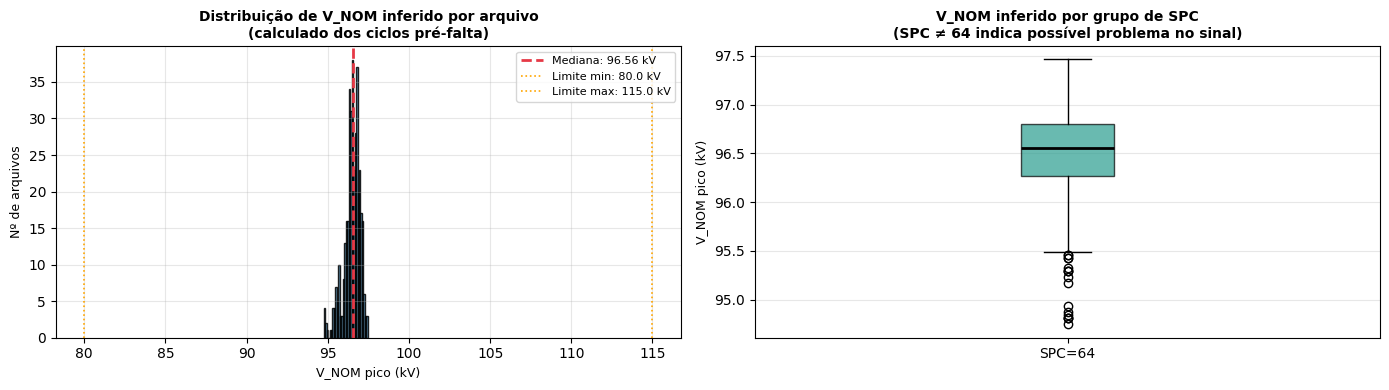

   📈 Diagnóstico salvo: 1_dados_preprocessados/exec_20260408_1953_60_64_6_384/diagnostico_inferencia.png


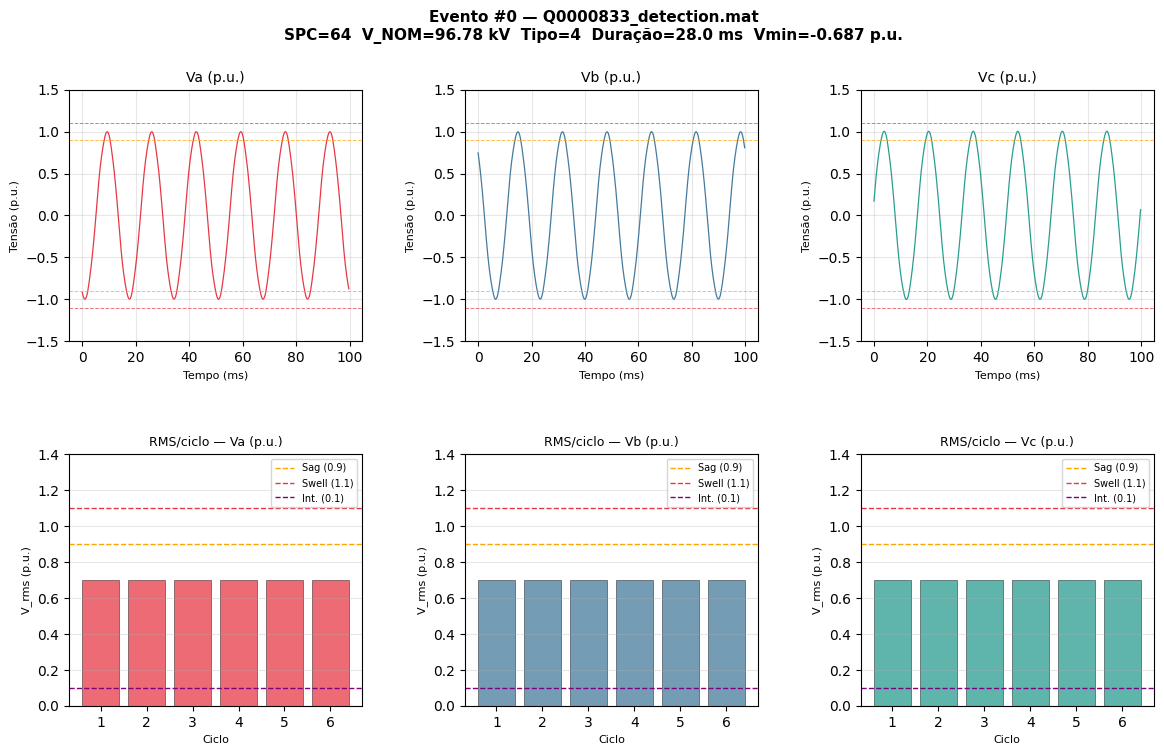

   📈 Gráfico salvo: evento_0000.png


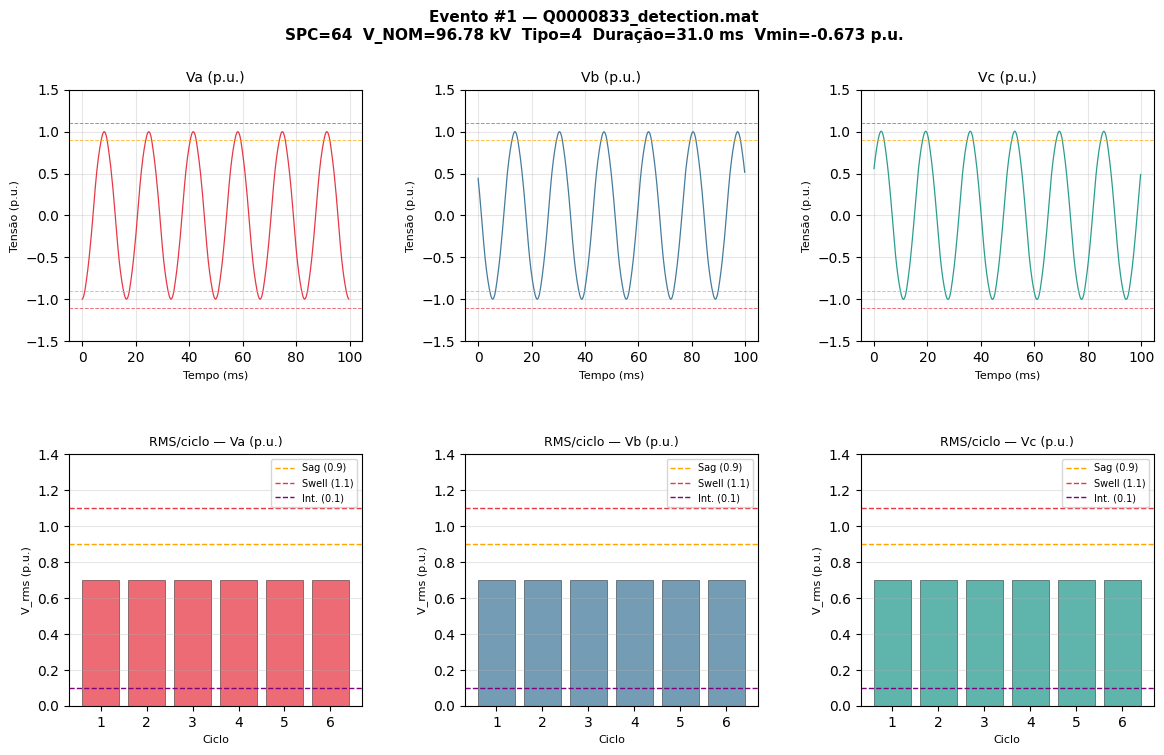

   📈 Gráfico salvo: evento_0001.png


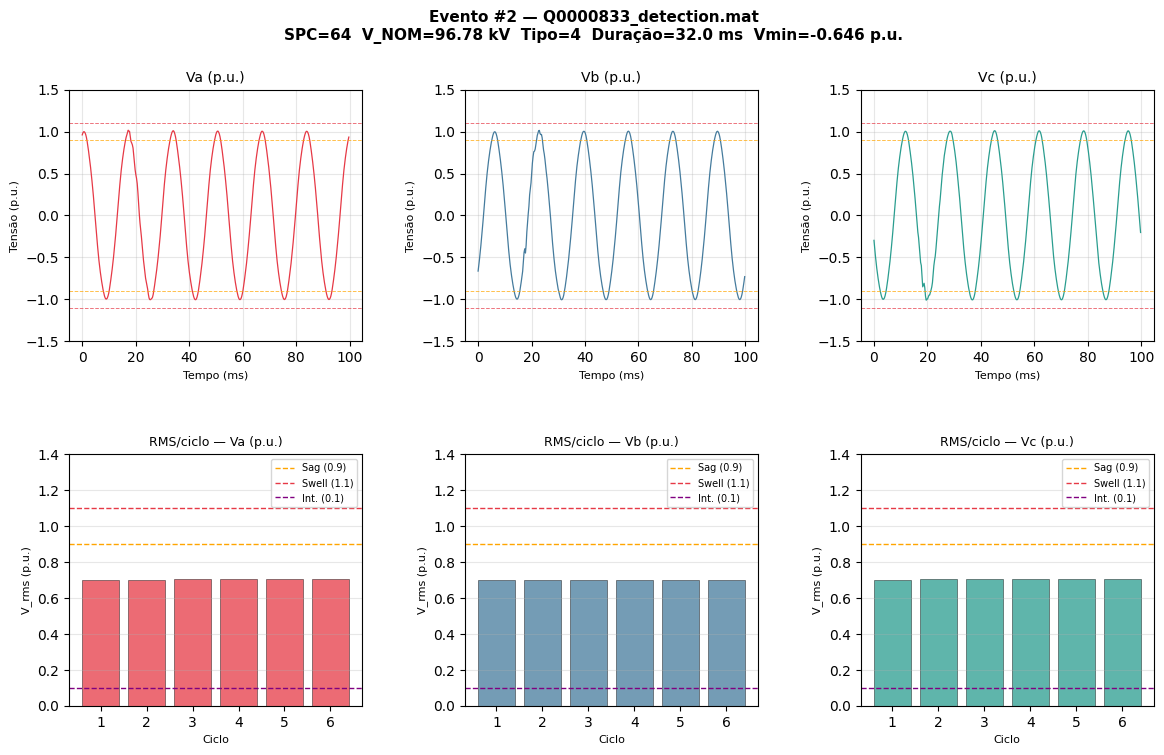

   📈 Gráfico salvo: evento_0002.png

📊 Resumo estatístico (primeiras 10 linhas):
 evento_idx                arquivo  tipo_evento  spc_usado  V_rms_min_pu  V_rms_max_pu  amp_pico_pos_pu  amp_pico_neg_pu classe_heuristica
          0 Q0000833_detection.mat          4.0         64      0.697904      0.701947         1.004348        -1.001338               sag
          1 Q0000833_detection.mat          4.0         64      0.698009      0.702185         1.004682        -1.002007               sag
          2 Q0000833_detection.mat          4.0         64      0.698035      0.706548         1.017057        -1.011371               sag
          3 Q0000833_detection.mat          4.0         64      0.701667      0.705740         1.008696        -1.005686               sag
          4 Q0000833_detection.mat          4.0         64      0.701381      0.705559         1.009365        -1.006020               sag
          5 Q0000833_detection.mat          4.0         64      0.698147      0.70630

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 13 — Executar visualizações
# ─────────────────────────────────────────────────────────────────────────────

try:
    plotar_diagnostico_inferencia(df_inferencia, OUTPUT_DIR)

    for idx in range(min(3, X_pu.shape[0])):
        plotar_evento(X_pu, df_aux, df_inferencia, idx_evento=idx)

    df_stats = resumo_estatistico(X_pu, df_aux, df_inferencia)
    df_stats.to_csv(os.path.join(OUTPUT_DIR, 'estatisticas_eventos.csv'), index=False)
    print(f"\n💾 Estatísticas salvas.")

except NameError:
    print("⚠️  Execute as células 9 e 10 antes de gerar visualizações.")

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 14 — Preparar tensor para o CAE (Módulo 2)
# ─────────────────────────────────────────────────────────────────────────────

def preparar_tensor_cae(X_pu: np.ndarray) -> np.ndarray:
    """
    Valida e converte o tensor para float32 (otimizado para GPU no Colab).
    Shape esperado: (N, WINDOW_SIZE_ALVO, 3).
    """
    assert X_pu.ndim == 3,             f"Esperado 3D, obtido {X_pu.ndim}D"
    assert X_pu.shape[1] == WINDOW_SIZE_ALVO, \
        f"Esperado {WINDOW_SIZE_ALVO} timesteps, obtido {X_pu.shape[1]}"
    assert X_pu.shape[2] == 3,         f"Esperado 3 canais, obtido {X_pu.shape[2]}"

    v_min_pu = float(X_pu.min())
    v_max_pu = float(X_pu.max())

    if abs(v_max_pu) > 1.5 or abs(v_min_pu) > 1.5:
        print(f"  ⚠️  Atenção: range p.u. = [{v_min_pu:.4f}, {v_max_pu:.4f}]")
        print(f"      Valores além de ±1.5 p.u. podem indicar erro de normalização.")
        print(f"      Revise o log df_inferencia para arquivos com V_NOM suspeito.")

    X_cae = X_pu.astype(np.float32)
    print(f"\n🔧 Tensor pronto para o CAE:")
    print(f"   Shape : {X_cae.shape}  (N_eventos × timesteps × fases)")
    print(f"   Dtype : {X_cae.dtype}")
    print(f"   Range : [{v_min_pu:.4f}, {v_max_pu:.4f}] p.u.")
    print(f"\n   ➡️  Próxima etapa: Módulo 2 — Autoencoder Convolucional (CAE)")
    return X_cae


try:
    X_cae = preparar_tensor_cae(X_pu)
    np.save(os.path.join(OUTPUT_DIR, 'X_cae_input.npy'), X_cae)
    print(f"   💾 Tensor CAE salvo: X_cae_input.npy")
except NameError:
    print("⚠️  Execute a Célula 9 primeiro.")

  ⚠️  Atenção: range p.u. = [-2.1199, 1.7635]
      Valores além de ±1.5 p.u. podem indicar erro de normalização.
      Revise o log df_inferencia para arquivos com V_NOM suspeito.

🔧 Tensor pronto para o CAE:
   Shape : (11928, 384, 3)  (N_eventos × timesteps × fases)
   Dtype : float32
   Range : [-2.1199, 1.7635] p.u.

   ➡️  Próxima etapa: Módulo 2 — Autoencoder Convolucional (CAE)
   💾 Tensor CAE salvo: X_cae_input.npy


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# FIM DO MÓDULO 1 — Pré-processamento
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*57)
print("✅ Módulo 1 — Pré-processamento concluído.")
print(f"   Arquivos gerados em: {OUTPUT_DIR}")
print("   Próximo módulo: Autoencoder Convolucional (CAE)")
print("="*57)


✅ Módulo 1 — Pré-processamento concluído.
   Arquivos gerados em: 1_dados_preprocessados/exec_20260408_1953_60_64_6_384
   Próximo módulo: Autoencoder Convolucional (CAE)
